In [1]:
import requests
import pandas as pd
import plotly.express as px

In [2]:
# IMF  = Interplanetary Magnetic Field

# Measured in Bx, By, Bz..

# Bx = sun to earth direction
# By = Sideways Magnetic Field
# Bz > 0 Earth Resists Interaction
# Bz < 0 Earth Connects more easily

In [3]:
url  = "https://services.swpc.noaa.gov/products/solar-wind/mag-7-day.json"

response  = requests.get(url)

print(response.status_code)

200


In [4]:
data = response.json()

print(type(data))
print(len(data))

<class 'list'>
9658


In [5]:
print(data[0])

['time_tag', 'bx_gsm', 'by_gsm', 'bz_gsm', 'lon_gsm', 'lat_gsm', 'bt']


In [6]:
print(data[1])

['2026-06-20 14:03:00.000', '1.88', '5.70', '-1.45', '71.73', '-13.59', '6.20']


In [7]:
df = pd.DataFrame(data[1:], columns =data[0])
df.tail()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
9652,2026-06-27 13:55:00.000,0.77,-2.61,-0.13,286.46,-2.74,2.77
9653,2026-06-27 13:56:00.000,0.61,-2.70,-0.47,282.80,-9.60,2.81
9654,2026-06-27 13:57:00.000,0.72,-2.70,-0.43,285.00,-8.67,2.83
9655,2026-06-27 13:58:00.000,0.72,-2.54,-0.39,285.84,-8.38,2.74
9656,2026-06-27 13:59:00.000,1.11,-2.42,-0.32,294.52,-6.80,2.72


In [8]:
print(type(data))

<class 'list'>


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9657 entries, 0 to 9656
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time_tag  9657 non-null   str  
 1   bx_gsm    9657 non-null   str  
 2   by_gsm    9657 non-null   str  
 3   bz_gsm    9657 non-null   str  
 4   lon_gsm   9657 non-null   str  
 5   lat_gsm   9657 non-null   str  
 6   bt        9657 non-null   str  
dtypes: str(7)
memory usage: 1017.1 KB
None


In [10]:
df["time_tag"] = pd.to_datetime(df["time_tag"])

numeric_cols = ["bx_gsm","by_gsm","bz_gsm","lon_gsm","lat_gsm","bt"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9657 entries, 0 to 9656
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time_tag  9657 non-null   datetime64[us]
 1   bx_gsm    9657 non-null   float64       
 2   by_gsm    9657 non-null   float64       
 3   bz_gsm    9657 non-null   float64       
 4   lon_gsm   9657 non-null   float64       
 5   lat_gsm   9657 non-null   float64       
 6   bt        9657 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 528.2 KB


In [12]:
df.describe()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
count,9657,9657.000000,9657.000000,9657.000000,9657.000000,9657.000000,9657.000000
mean,2026-06-24 01:00:31.686859,1.235144,-2.048094,0.157028,243.351465,1.494072,6.357112
min,2026-06-20 14:03:00,-8.670000,-14.250000,-10.490000,0.180000,-87.700000,0.430000
25%,2026-06-22 06:35:00,-2.320000,-4.230000,-1.500000,166.670000,-14.980000,4.410000
50%,2026-06-23 23:28:00,1.270000,-2.470000,0.320000,281.340000,3.250000,5.660000
75%,2026-06-25 21:02:00,4.010000,0.630000,1.950000,314.160000,20.080000,7.090000
max,2026-06-27 13:59:00,12.860000,6.760000,9.510000,359.990000,88.950000,15.320000
std,NaN,4.399866,3.888689,2.689196,89.178151,27.977797,2.780611


In [15]:
df.loc[df["bz_gsm"].idxmin()]

time_tag    2026-06-24 20:33:00
bx_gsm                     0.24
by_gsm                    -7.56
bz_gsm                   -10.49
lon_gsm                  271.84
lat_gsm                  -54.22
bt                        12.95
Name: 6074, dtype: object

In [15]:
# usally at daytime earths magnetic field generally points northward
# therefore negative IMF Bz means southward 
# Opposite magnetic fields meeting leads to magnetic reconnection which make energy transfer easy into the earth

In [26]:
(df["bz_gsm"]<0).sum()

np.int64(4627)

In [27]:
(df["bz_gsm"]>0).sum()

np.int64(5306)

In [28]:
(df["bz_gsm"]==0).sum()

np.int64(22)

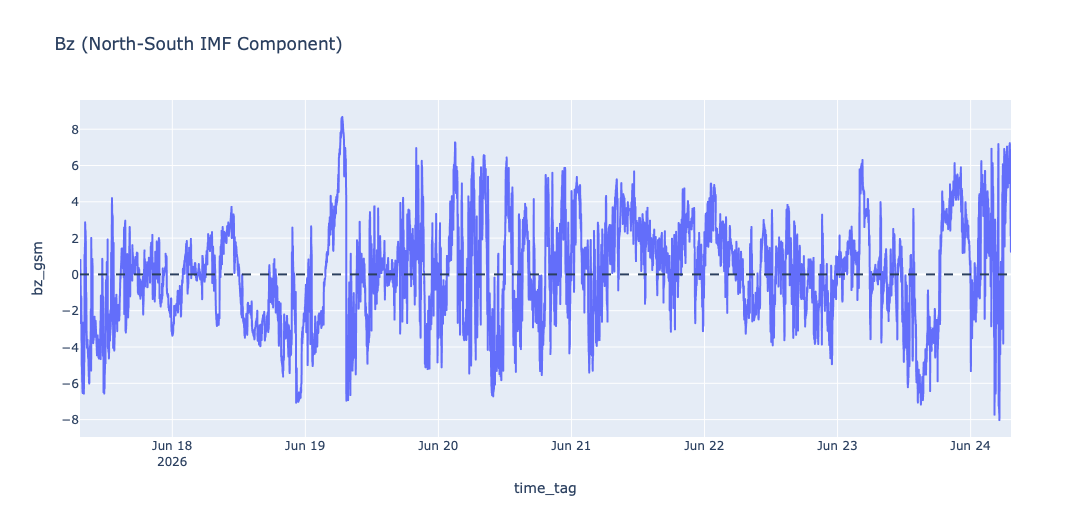

In [29]:


fig = px.line(
    df,
    x="time_tag",
    y="bz_gsm",
    title="Bz (North-South IMF Component)"
)

fig.update_layout(
    width=1200,
    height=500
)
fig.add_hline(
    y=0,
    line_dash="dash"
)

fig

In [30]:
df["bt"].describe()

count    9955.000000
mean        6.216292
std         2.198992
min         0.620000
25%         4.770000
50%         5.950000
75%         7.210000
max        13.470000
Name: bt, dtype: float64

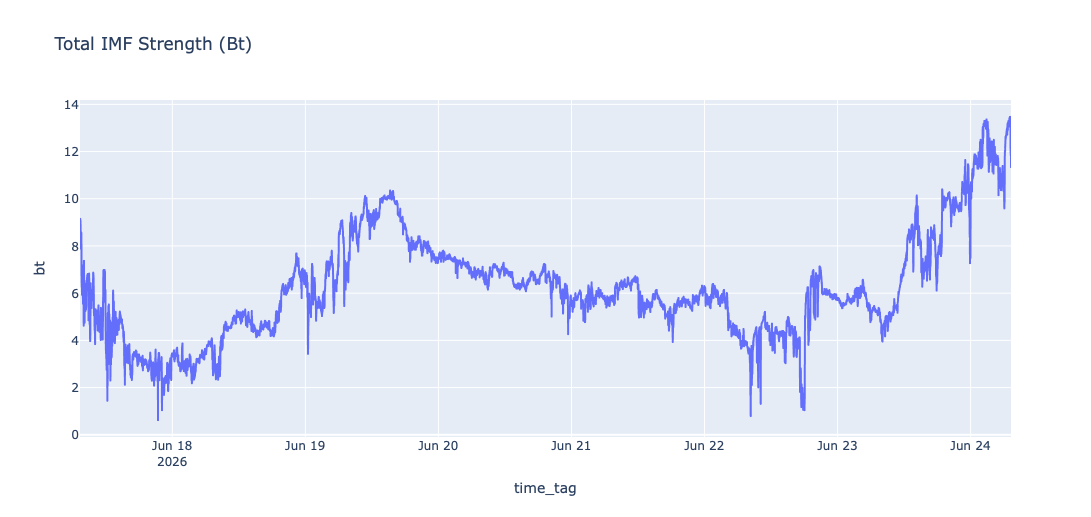

In [31]:
fig = px.line(
    df,
    x="time_tag",
    y="bt",
    title="Total IMF Strength (Bt)"
)

fig.update_layout(
    width=1200,
    height=500
)

fig

In [22]:
# Direction Matters Bz
# Strength Matters Bt

In [14]:
df.loc[df["bz"].idxmin()]

KeyError: 'bz'

In [33]:
#Strong field alone does not imply
# geomagnetic storm potential.

# Bz direction remains critical


In [34]:
df[["bx_gsm","by_gsm","bz_gsm","bt"]].corr()

,bx_gsm,by_gsm,bz_gsm,bt
bx_gsm,1.000000,-0.542441,0.029589,0.137461
by_gsm,-0.542441,1.000000,0.019210,-0.104073
bz_gsm,0.029589,0.019210,1.000000,0.142447
bt,0.137461,-0.104073,0.142447,1.000000


In [35]:
# Bz behaves largely Independent (Bx & By)

# Day 4 Bonus Analysis

In [36]:
solar_url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

solar_response = requests.get(solar_url)

solar_data = solar_response.json()

In [37]:
solar_df = pd.DataFrame(
    solar_data[1:],
    columns=solar_data[0]
)

In [38]:
solar_df.head()

,time_tag,density,speed,temperature
0,2026-06-17 07:34:00.000,7.86,421.2,127420
1,2026-06-17 07:35:00.000,8.03,420.9,117878
2,2026-06-17 07:36:00.000,7.85,419.0,128821
3,2026-06-17 07:37:00.000,8.40,423.0,142693
4,2026-06-17 07:38:00.000,9.41,429.2,159363


In [39]:
solar_df["time_tag"] = pd.to_datetime(solar_df["time_tag"])

for col in ["density", "speed", "temperature"]:
    solar_df[col] = pd.to_numeric(
        solar_df[col],
        errors="coerce"
    )

In [40]:
solar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9874 entries, 0 to 9873
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9874 non-null   datetime64[us]
 1   density      9874 non-null   float64       
 2   speed        9874 non-null   float64       
 3   temperature  9874 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 308.7 KB


In [41]:
merged_df = pd.merge(
    solar_df,
    df,
    on="time_tag",
    how="inner"
)

In [42]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9861 entries, 0 to 9860
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9861 non-null   datetime64[us]
 1   density      9861 non-null   float64       
 2   speed        9861 non-null   float64       
 3   temperature  9861 non-null   int64         
 4   bx_gsm       9861 non-null   float64       
 5   by_gsm       9861 non-null   float64       
 6   bz_gsm       9861 non-null   float64       
 7   lon_gsm      9861 non-null   float64       
 8   lat_gsm      9861 non-null   float64       
 9   bt           9861 non-null   float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 770.5 KB


In [43]:
merged_df[
    [
        "density",
        "speed",
        "temperature",
        "bx_gsm",
        "by_gsm",
        "bz_gsm",
        "bt"
    ]
].corr()

,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,bt
density,1.000000,0.205194,0.132507,0.366688,-0.139512,-0.162901,0.257000
speed,0.205194,1.000000,0.723915,0.036363,0.186436,-0.011669,0.003487
temperature,0.132507,0.723915,1.000000,-0.000326,-0.025181,0.040748,0.082923
bx_gsm,0.366688,0.036363,-0.000326,1.000000,-0.550519,0.027518,0.133474
by_gsm,-0.139512,0.186436,-0.025181,-0.550519,1.000000,0.018773,-0.109227
bz_gsm,-0.162901,-0.011669,0.040748,0.027518,0.018773,1.000000,0.141261
bt,0.257000,0.003487,0.082923,0.133474,-0.109227,0.141261,1.000000


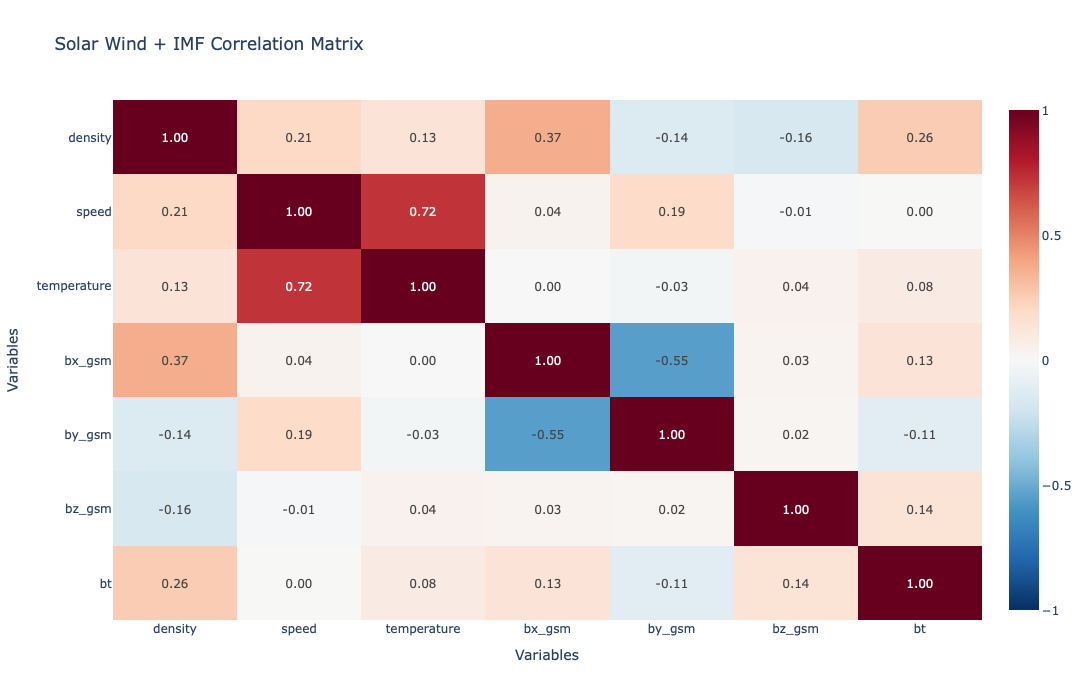

In [44]:
import plotly.express as px

corr_matrix = merged_df[
    [
        "density",
        "speed",
        "temperature",
        "bx_gsm",
        "by_gsm",
        "bz_gsm",
        "bt"
    ]
].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Solar Wind + IMF Correlation Matrix"
)

fig.update_layout(
    width=900,
    height=700,
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

Merged Solar Wind and IMF analysis showed that
solar wind speed, density, and temperature have
little relationship with Bz orientation.

The strongest relationship observed was between
speed and temperature (0.81).

This suggests that plasma properties and magnetic
field orientation should be analyzed separately
when assessing space weather conditions.

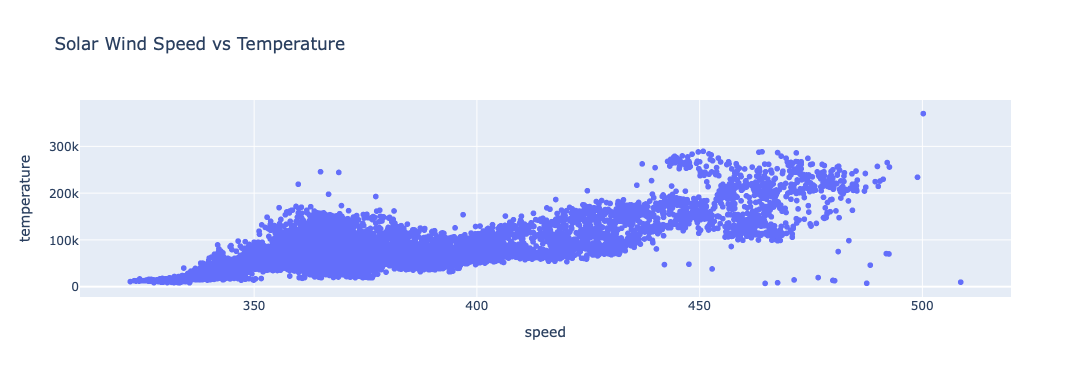

In [45]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="speed",
    y="temperature",
    title="Solar Wind Speed vs Temperature"
)

fig

# Bz Persistance


In [46]:
df["negative_bz"] = df["bz_gsm"] < 0

In [47]:
groups = (df["negative_bz"] != df["negative_bz"].shift()).cumsum()

In [48]:
df["group"] = groups

In [49]:
negative_intervals = (
    df[df["negative_bz"]]
    .groupby("group")
    .size()
)

In [50]:
negative_intervals.max()

np.int64(318)

In [51]:
longest_group = negative_intervals.idxmax()

longest_group

np.int64(119)

In [52]:
longest_event = df[df["group"] == longest_group]

longest_event.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
1696,2026-06-18 12:06:00,5.06,0.01,-0.27,0.09,-3.02,5.07,True,119
1697,2026-06-18 12:07:00,5.04,-0.24,-0.54,357.27,-6.10,5.07,True,119
1698,2026-06-18 12:08:00,4.99,-0.40,-0.57,355.44,-6.45,5.04,True,119
1699,2026-06-18 12:09:00,4.96,-0.67,-0.55,352.35,-6.30,5.03,True,119
1700,2026-06-18 12:10:00,4.94,-0.99,-0.49,348.71,-5.58,5.06,True,119


In [53]:
longest_event.tail()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
2009,2026-06-18 17:22:00,1.98,3.02,-2.99,56.69,-39.65,4.72,True,119
2010,2026-06-18 17:23:00,2.03,3.01,-3.02,56.05,-39.74,4.73,True,119
2011,2026-06-18 17:24:00,1.89,3.22,-2.81,59.62,-36.94,4.67,True,119
2012,2026-06-18 17:25:00,2.10,3.13,-2.74,56.10,-36.04,4.67,True,119
2013,2026-06-18 17:26:00,3.37,3.33,-0.58,44.65,-6.95,4.82,True,119


In [56]:
start_time = longest_event["time_tag"].min()
end_time = longest_event["time_tag"].max()

print(start_time)
print(end_time)

2026-06-18 12:06:00
2026-06-18 17:26:00


In [57]:
duration = end_time - start_time

print(duration)

0 days 05:20:00


# KP Index Analysis

In [58]:
merged_df[
    (merged_df["time_tag"] >= "2026-06-18 21:00")
    &
    (merged_df["time_tag"] <= "2026-06-19 00:00")
]

,time_tag,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
2143,2026-06-18 21:00:00,6.57,368.0,36513,0.77,5.49,-2.80,82.01,-26.76,6.21
2144,2026-06-18 21:01:00,6.54,369.1,38030,0.74,5.46,-2.89,82.31,-27.69,6.23
2145,2026-06-18 21:02:00,7.01,371.3,35256,1.17,5.34,-2.94,77.67,-28.24,6.21
2146,2026-06-18 21:03:00,6.45,369.8,38942,1.05,5.47,-2.90,79.14,-27.51,6.29
2147,2026-06-18 21:04:00,6.40,369.3,37313,1.37,5.34,-3.10,75.59,-29.35,6.32
...,...,...,...,...,...,...,...,...,...,...
2319,2026-06-18 23:56:00,8.65,372.4,32284,4.06,4.94,-1.83,50.52,-15.98,6.66
2320,2026-06-18 23:57:00,7.68,373.1,38834,3.85,5.44,-1.73,54.72,-14.54,6.88
2321,2026-06-18 23:58:00,8.07,372.0,22356,4.24,4.90,-1.68,49.14,-14.51,6.72
2322,2026-06-18 23:59:00,8.94,374.8,37083,4.54,4.63,-1.44,45.59,-12.51,6.64


In [59]:
merged_df.loc[
    merged_df["time_tag"] == "2026-06-19 00:00:00"
]

,time_tag,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
2323,2026-06-19,8.88,374.6,35993,4.43,4.68,-1.29,46.54,-11.31,6.57


In [60]:
merged_df[
    (merged_df["time_tag"] >= "2026-06-18 18:00")
    &
    (merged_df["time_tag"] <= "2026-06-19 03:00")
][["time_tag","speed","density","temperature","bz_gsm","bt"]].describe()

,time_tag,speed,density,temperature,bz_gsm,bt
count,541,541.000000,541.000000,541.000000,541.000000,541.000000
mean,2026-06-18 22:30:00,371.697782,7.371072,49575.480591,-2.869519,5.994104
min,2026-06-18 18:00:00,356.700000,4.010000,19212.000000,-7.070000,3.430000
25%,2026-06-18 20:15:00,367.700000,6.270000,36006.000000,-3.940000,5.440000
50%,2026-06-18 22:30:00,371.400000,7.140000,41426.000000,-2.810000,6.110000
75%,2026-06-19 00:45:00,375.600000,8.380000,64215.000000,-1.620000,6.620000
max,2026-06-19 03:00:00,389.300000,12.940000,120138.000000,2.650000,7.680000
std,NaN,5.587684,1.511103,19164.174601,2.019868,0.820246
